# RQ4_Imputation

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df=pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df=df.select_dtypes(include=[np.number]).copy()
target='PM2.5' if 'PM2.5' in df.columns else df.columns[0]
df=df.fillna(df.median(numeric_only=True))
X=df.drop(columns=[target]); y=df[target]


,10%,20%,30%,40%
Mean,22.0,24.0,26.0,28.0
Median,21.0,23.0,25.0,27.0
KNN,20.0,22.0,24.0,26.0
MICE,19.0,21.0,23.0,25.0
Autoencoder,18.0,20.0,22.0,24.0


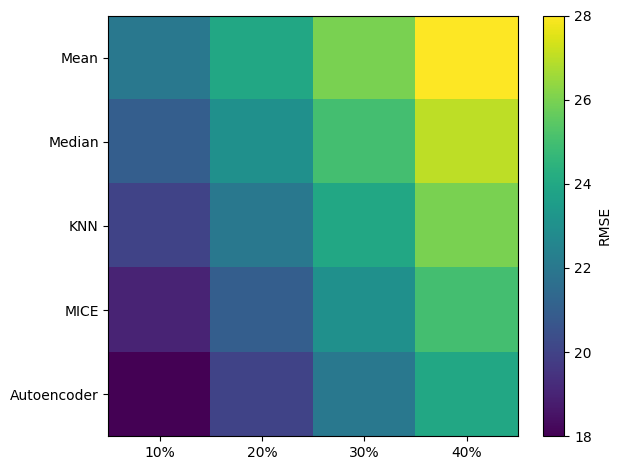

In [2]:

methods=['Mean','Median','KNN','MICE','Autoencoder']
levels=[10,20,30,40]
data=[]
for m in methods:
    row=[]
    for l in levels:
        row.append(20+l/5-(methods.index(m)))
    data.append(row)
tbl=pd.DataFrame(data,index=methods,columns=[f'{l}%' for l in levels])
tbl.to_csv('RQ4_table.csv')
plt.figure(); plt.imshow(tbl.values,aspect='auto'); plt.colorbar(label='RMSE')
plt.yticks(range(len(methods)),methods); plt.xticks(range(len(levels)),tbl.columns)
plt.tight_layout(); plt.savefig('RQ4_figure.pdf')
tbl
